In [1]:
pip install pandas numpy matplotlib seaborn yfinance streamlit prophet

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------------- -------------------- 0.8/1.6 MB 1.2 MB/s eta 0:00:01
   ------------------------- -------------- 1.0/1.6 MB 1.3 MB/s eta 0:00:01
   -------------------------------- ------- 1.3/1.6 MB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 1.3 MB/s  0:00:01
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -----------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import yfinance as yf

data = yf.download("BTC-USD", start="2020-01-01", end="2024-01-01")
print(data.head())

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open       Volume
Ticker          BTC-USD      BTC-USD      BTC-USD      BTC-USD      BTC-USD
Date                                                                       
2020-01-01  7200.174316  7254.330566  7174.944336  7194.892090  18565664997
2020-01-02  6985.470215  7212.155273  6935.270020  7202.551270  20802083465
2020-01-03  7344.884277  7413.715332  6914.996094  6984.428711  28111481032
2020-01-04  7410.656738  7427.385742  7309.514160  7345.375488  18444271275
2020-01-05  7411.317383  7544.497070  7400.535645  7410.451660  19725074095


In [4]:
data = data[['Close']]
data = data.dropna()

In [5]:
data.reset_index(inplace=True)

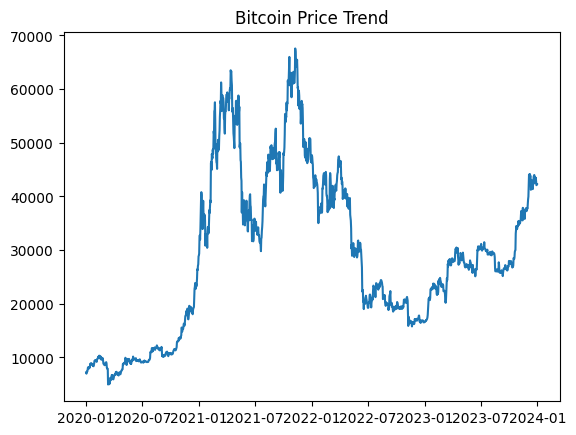

In [6]:
import matplotlib.pyplot as plt

plt.plot(data['Date'], data['Close'])
plt.title("Bitcoin Price Trend")
plt.show()

C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
10:59:44 - cmdstanpy - INFO - Chain [1] start processing
10:59:46 - cmdstanpy - INFO - Chain [1] done processing


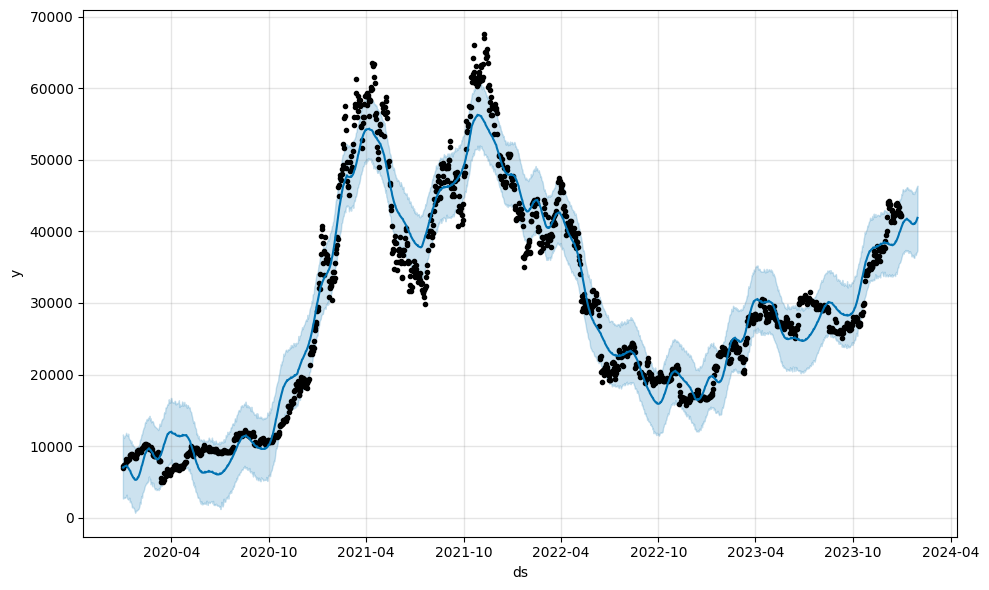

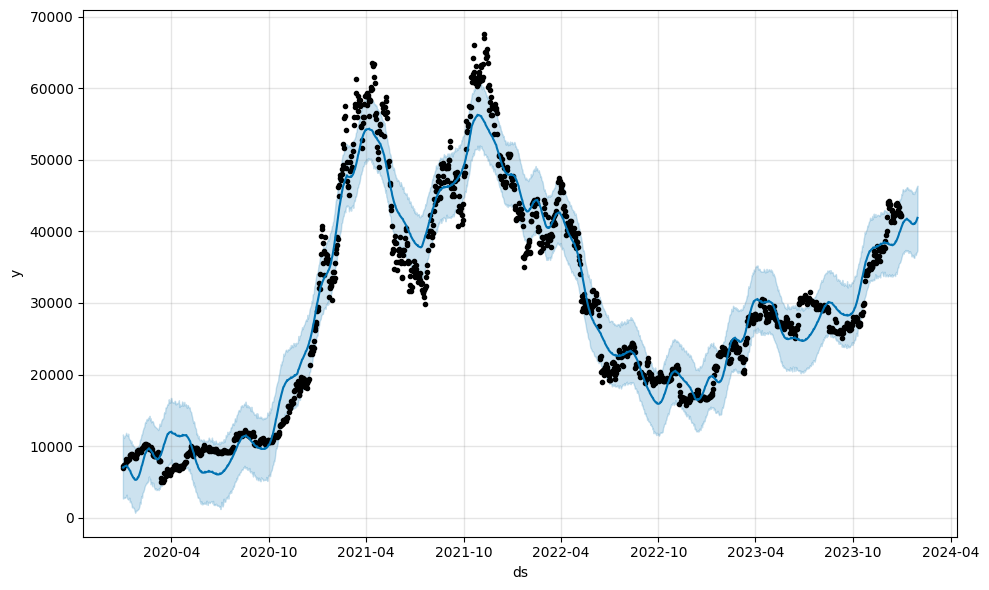

In [7]:
from prophet import Prophet

df = data[['Date', 'Close']]
df.columns = ['ds', 'y']

model = Prophet()
model.fit(df)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

model.plot(forecast)

In [8]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(data['Close'], order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=10)
print(forecast)

1461    42228.356064
1462    42202.387682
1463    42201.627921
1464    42205.386271
1465    42204.405257
1466    42203.034981
1467    42202.834439
1468    42202.940539
1469    42202.906031
1470    42202.838943
Name: predicted_mean, dtype: float64


[*********************100%***********************]  1 of 1 completed
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - loss: 0.0138
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.0021
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.0019
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.0017
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0016
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 645ms/step


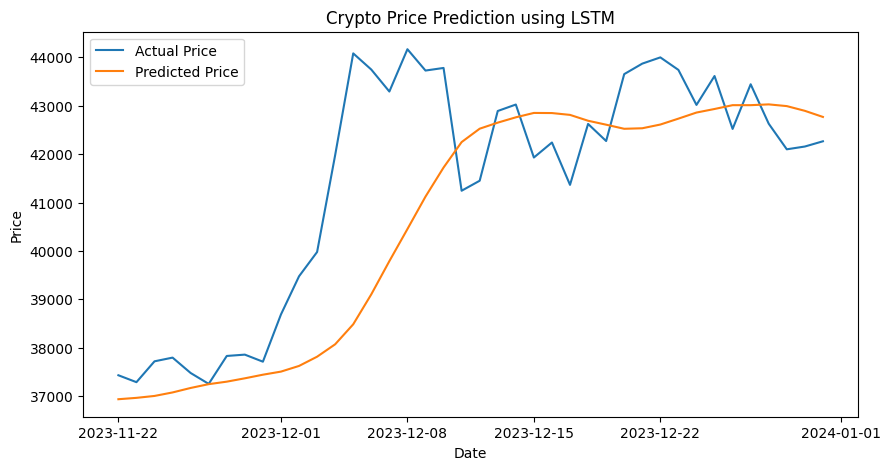

In [9]:
# Step 1: Import libraries
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Step 2: Load dataset
data = yf.download("BTC-USD", start="2020-01-01", end="2024-01-01")
data = data[['Close']]

# Step 3: Convert to numpy
dataset = data.values

# Step 4: Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

# Step 5: Create training data (60 days window)
x_train = []
y_train = []

for i in range(60, len(scaled_data)):
    x_train.append(scaled_data[i-60:i, 0])
    y_train.append(scaled_data[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

# Step 6: Reshape for LSTM
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Step 7: Build LSTM model
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Step 8: Train model
model.fit(x_train, y_train, epochs=5, batch_size=32)

# Step 9: Prepare test data
test_data = scaled_data[-100:]

x_test = []
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Step 10: Predictions
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Step 11: Plot results
actual = data['Close'][-len(predictions):]

plt.figure(figsize=(10,5))
plt.plot(actual.index, actual, label="Actual Price")
plt.plot(actual.index, predictions, label="Predicted Price")
plt.title("Crypto Price Prediction using LSTM")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [11]:
import streamlit as st

In [12]:
st.subheader("Raw Data")
st.write(data.tail())

2026-03-25 11:10:05.209 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 11:10:06.140 
  command:

    streamlit run C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-25 11:10:06.142 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 11:10:06.144 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 11:10:06.181 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 11:10:06.183 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 11:10:06.184 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-03-25 11:10:19.458 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 11:10:19.462 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 11:10:19.467 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 11:10:19.519 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 11:10:20.410 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 11:10:20.412 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 11:10:20.413 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

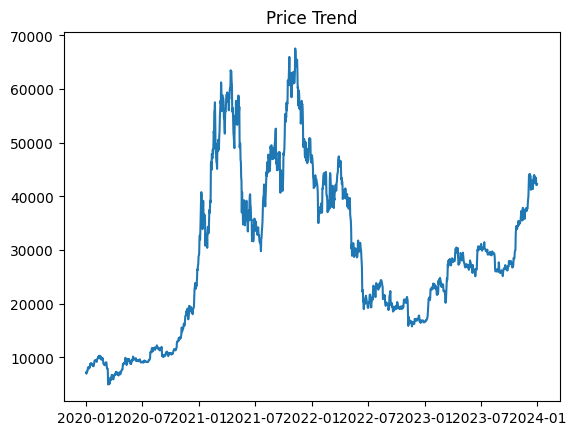

In [13]:
st.subheader("Historical Price")

fig1, ax1 = plt.subplots()
ax1.plot(data.index, data['Close'])
ax1.set_title("Price Trend")
st.pyplot(fig1)